In [55]:
import pandas as pd

In [56]:
df = pd.read_csv("/content/Data/healthcare_data.csv")

In [57]:
df.head()

,Patient_ID,Name,Age,Gender,Diagnosis,Treatment,Doctor,Cost,Discount,Visit_Date
0,1,Alice,52,Female,Heart Disease,Surgery,Dr. Johnson,19019.21,NaN,2024-04-16
1,2,James,72,Female,Diabetes,Medication,Dr. Smith,12013.30,NaN,2024-04-12
2,3,Olivia,83,Male,Arthritis,Surgery,Dr. Lee,2089.50,0.0,2024-03-28
3,4,Bob,24,Female,Flu,Surgery,Dr. Johnson,13052.68,0.1,2024-11-04
4,5,Alice,2,Male,Covid-19,Therapy,Dr. Wilson,14467.78,0.0,2024-10-20


# Healthcare Data Cleaning & Analysis

**Dataset:** `healthcare_data.csv` (100 patient records with intentionally dirty data)

**Learning Goals**
- Handle real-world unorganized healthcare data.
- Apply data cleaning & preprocessing.
- Perform manipulation & aggregation for insights.
- Develop business-oriented analytical thinking.

---

## Part A:  Questions (Q1–Q3)


In [58]:
df['Cost'] = pd.to_numeric(df['Cost'], errors='coerce')
df['Discount'] = pd.to_numeric(df['Discount'], errors='coerce')

In [59]:
df.head()

,Patient_ID,Name,Age,Gender,Diagnosis,Treatment,Doctor,Cost,Discount,Visit_Date
0,1,Alice,52,Female,Heart Disease,Surgery,Dr. Johnson,19019.21,NaN,2024-04-16
1,2,James,72,Female,Diabetes,Medication,Dr. Smith,12013.30,NaN,2024-04-12
2,3,Olivia,83,Male,Arthritis,Surgery,Dr. Lee,2089.50,0.0,2024-03-28
3,4,Bob,24,Female,Flu,Surgery,Dr. Johnson,13052.68,0.1,2024-11-04
4,5,Alice,2,Male,Covid-19,Therapy,Dr. Wilson,14467.78,0.0,2024-10-20


In [60]:
#Filling the cost with median
df['Cost'] = df.groupby('Diagnosis')['Cost'].transform(lambda x:x.fillna(x.median()))

In [61]:
#Filling the discount with Zero
df['Discount'] = df['Discount'].fillna(0)

### Q2. Hidden Duplicate Patients
**Goal**
- Standardize patient names by stripping spaces (e.g., `"John "` → `"John"`).
- Identify duplicates on **(Name, Age, Diagnosis)**.
- Remove duplicates and **report how many were removed**.


In [62]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.strip()

In [63]:
before = len(df)
df = df.drop_duplicates(subset=['Name', 'Age', 'Diagnosis'])
after = len(df)
print("Before:", before, "\nAfter", after)
print(f"Duplicates removed: {before - after}")

Before: 100 
After 98
Duplicates removed: 2


### Q3. Revenue Calculation
**Goal**
- Create `Final_Bill = Cost * (1 - Discount)`  
- Find the patient with **maximum Final_Bill** and report:
  - Name, Diagnosis, Doctor, Final_Bill


In [64]:
df["Final_Bill"] = df["Cost"] * (1 - df["Discount"])

In [65]:
df

,Patient_ID,Name,Age,Gender,Diagnosis,Treatment,Doctor,Cost,Discount,Visit_Date,Final_Bill
0,1,Alice,52,Female,Heart Disease,Surgery,Dr. Johnson,19019.21,0.00,2024-04-16,19019.2100
1,2,James,72,Female,Diabetes,Medication,Dr. Smith,12013.30,0.00,2024-04-12,12013.3000
2,3,Olivia,83,Male,Arthritis,Surgery,Dr. Lee,2089.50,0.00,2024-03-28,2089.5000
3,4,Bob,24,Female,Flu,Surgery,Dr. Johnson,13052.68,0.10,2024-11-04,11747.4120
4,5,Alice,2,Male,Covid-19,Therapy,Dr. Wilson,14467.78,0.00,2024-10-20,14467.7800
...,...,...,...,...,...,...,...,...,...,...,...
95,96,Alice,30,Female,Heart Disease,Observation,Dr. Smith,19462.91,0.00,2024-12-30,19462.9100
96,97,Bob,51,Male,Hypertension,Medication,Dr. Johnson,17851.73,0.00,2024-10-09,17851.7300
97,98,Olivia,27,Female,Hypertension,Observation,Dr. Brown,15916.74,0.10,2024-10-12,14325.0660
98,99,James,28,Female,Hypertension,Medication,Dr. Lee,13411.59,0.00,2024-11-12,13411.5900


In [66]:
max_idx = df["Final_Bill"].idxmax()
top_row = df.loc[max_idx, ["Name", "Diagnosis", "Doctor", "Final_Bill"]]

In [67]:
top_row

,95
Name,Alice
Diagnosis,Heart Disease
Doctor,Dr. Smith
Final_Bill,19462.91


In [68]:
doctor_summary = df.groupby("Doctor").agg(
    Patients_Treated=("Name", "count"),
    Total_Revenue=("Final_Bill", "sum")
).reset_index()

In [69]:
doctor_summary

,Doctor,Patients_Treated,Total_Revenue
0,Dr. Brown,15,129352.9005
1,Dr. Johnson,22,183358.5155
2,Dr. Lee,23,230665.6350
3,Dr. Smith,20,202372.2195
4,Dr. Wilson,18,149651.3270


## Part B: Medium Questions

### Q4. Disease & Cost Analysis
**Goal**
- Group by `Diagnosis` and compute:
  - **Total patients** per disease
  - **Average Final_Bill** per disease  
- Identify: Which disease costs **most on average**?

### Q5. Doctor Performance
**Goal**
- For each `Doctor`, compute:
  - **Number of patients** treated
  - **Total revenue** generated (`Final_Bill`)
- Identify the doctor with the **highest revenue**.


In [73]:
top_doctor = doctor_summary.loc[doctor_summary["Total_Revenue"].idxmax()]

print("\nDoctor performance summary:")
print(doctor_summary)
print("----"*17)
print("\nDoctor with highest revenue:")
print(top_doctor.to_string())


Doctor performance summary:
        Doctor  Patients_Treated  Total_Revenue
0    Dr. Brown                15    129352.9005
1  Dr. Johnson                22    183358.5155
2      Dr. Lee                23    230665.6350
3    Dr. Smith                20    202372.2195
4   Dr. Wilson                18    149651.3270
--------------------------------------------------------------------

Doctor with highest revenue:
Doctor                 Dr. Lee
Patients_Treated            23
Total_Revenue       230665.635


## Part C: Insights

### Q6. Age vs Disease Trend
**Goal**
- Create age groups: `0–18`, `19–35`, `36–60`, `61+`
- For each age group, find the **most common Diagnosis**
- Insight: Which age group is most vulnerable to which disease?

### Q7. Gender Bias in Treatment
**Goal**
- Compare **average Final_Bill** by `Gender`
- Identify which gender incurs **higher average costs**
- Suggest a possible reason (e.g., diseases mix, treatment types)

### Q8. Seasonal Patient Flow
**Goal**
- Extract **month** from `Visit_Date`
- Count **patients per month**
- Identify the **busiest month** for visits


/tmp/ipython-input-3912412967.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_disease_counts = df.groupby(["Age_Group", "Diagnosis"])["Name"].count().reset_index(name="Count")
/tmp/ipython-input-3912412967.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subset, x="Diagnosis", y="Count", ax=axes[i], palette="viridis")
/tmp/ipython-input-3912412967.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subset, x="Diagnosis", y="Count", ax=axes[i], palette="viridis")
/tmp/ipython-in

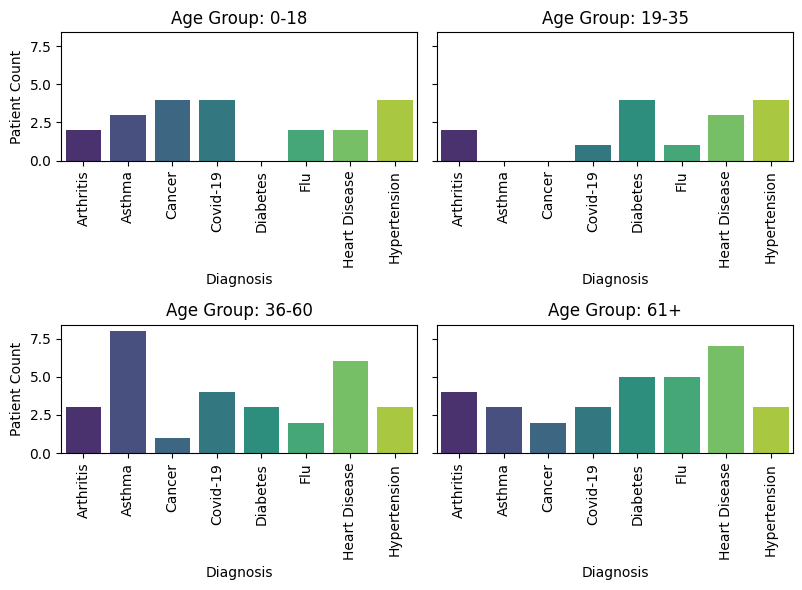

In [78]:
import seaborn as sns

df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

bins = [0, 18, 35, 60, float('inf')]
labels = ["0-18", "19-35", "36-60", "61+"]


df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)


age_disease_counts = df.groupby(["Age_Group", "Diagnosis"])["Name"].count().reset_index(name="Count")

age_groups = age_disease_counts["Age_Group"].unique()

fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharey=True)
axes = axes.flatten()

for i, group in enumerate(age_groups):
    subset = age_disease_counts[age_disease_counts["Age_Group"] == group]
    sns.barplot(data=subset, x="Diagnosis", y="Count", ax=axes[i], palette="viridis")
    axes[i].set_title(f"Age Group: {group}")
    axes[i].set_ylabel("Patient Count")
    axes[i].set_xlabel("Diagnosis")
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

## Q6. Age vs Disease Trend

### Age Group: 0–18
- **Most common diagnosis:** **Hypertension** and **cancer and covid**(tie)
- **Insight:** Unexpectedly high hypertension cases among minors in this dataset; infectious diseases (Cancer/Covid-19 bars are lower than Hypertension) trail behind.

---

### Age Group: 19–35
- **Most common diagnosis:** **Diabetes** and **Hypertension** (tie)
- **Insight:** Early lifestyle risk shows up strongly in young adults.

---

### Age Group: 36–60
- **Most common diagnosis:** **Asthma** (Heart Disease is second)
- **Insight:** cardiovascular risks risisng.

---

### Age Group: 61+
- **Most common diagnosis:** **Heart Disease** (Flu/Diabetes next) and (Rest of the Disease are also notable)


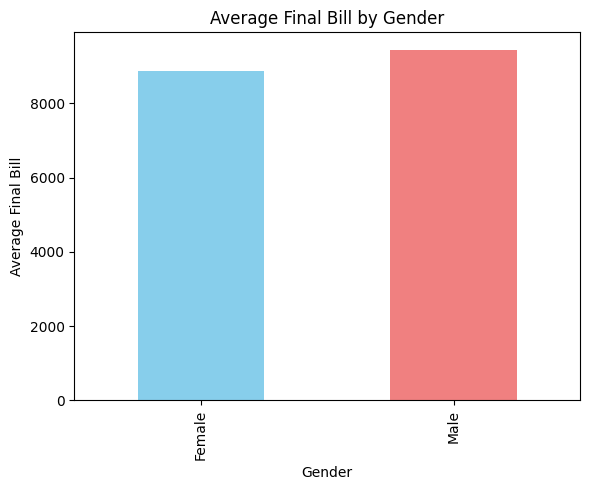

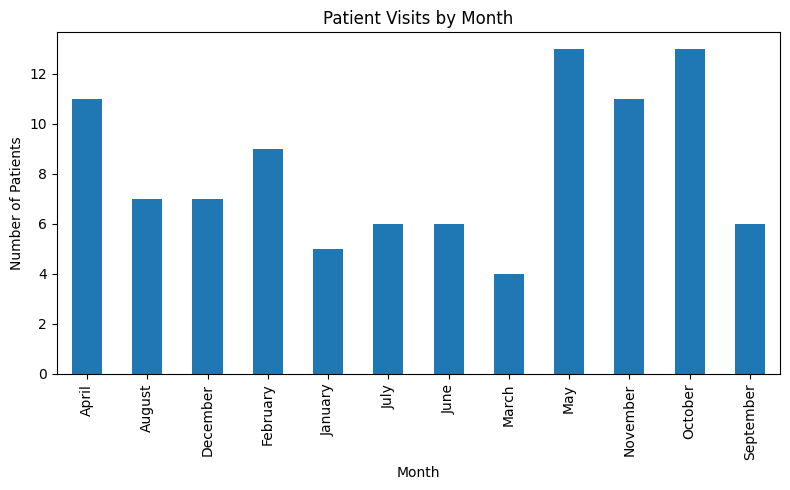

In [79]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
df.groupby("Gender")["Final_Bill"].mean().plot(kind="bar", color=["skyblue","lightcoral"])
plt.title("Average Final Bill by Gender")
plt.ylabel("Average Final Bill")
plt.xlabel("Gender")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8,5))
df["Visit_Date"] = pd.to_datetime(df["Visit_Date"], errors="coerce")
df["Visit_Date"].dt.month_name().value_counts().sort_index().plot(kind="bar")
plt.title("Patient Visits by Month")
plt.ylabel("Number of Patients")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

- **Gender:** Males incur higher treatment costs on average.  
- **Seasonality:** May and October are the busiest months for hospital visits, while March and January are the least busy.